In [1]:
# %% [cell 1] 导入库与全局设置
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（Windows 常用 SimHei，Mac 可用 'PingFang HK'）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang HK']
plt.rcParams['axes.unicode_minus'] = False

# 路径
root = r"C:\Users\mingar\Downloads\Finance\homework\ex03"
data_clean = os.path.join(root, "data_clean")
output_fig = os.path.join(root, "output", "figures")
os.makedirs(output_fig, exist_ok=True)

# 读取最终分析数据
df = pd.read_csv(os.path.join(data_clean, "analysis_data.csv"))
print("数据读取完毕，观测数:", df.shape[0])

数据读取完毕，观测数: 38385


In [2]:
# %% [cell 2] 2.1 描述性统计表（带 t 检验）
vars_list = ['lev', 'npr', 'size', 'tang', 'growth', 'ndts']
labels = {
    'lev': 'Lev',
    'npr': 'NPR',
    'size': 'Size',
    'tang': 'Tang',
    'growth': 'Growth',
    'ndts': 'NDTS'
}

# 分组计算统计量
def desc_stats(series):
    return pd.Series({
        'N': series.count(),
        'Mean': series.mean(),
        'SD': series.std(),
        'P10': series.quantile(0.10),
        'P25': series.quantile(0.25),
        'Median': series.quantile(0.50),
        'P75': series.quantile(0.75),
        'P90': series.quantile(0.90)
    })

# 全样本
all_stats = df[vars_list].apply(desc_stats).T
# 分 SOE
soe0 = df[df['soe']==0][vars_list].apply(desc_stats).T
soe1 = df[df['soe']==1][vars_list].apply(desc_stats).T

# t 检验与显著性标注
t_test_results = {}
for v in vars_list:
    g0 = df[df['soe']==0][v].dropna()
    g1 = df[df['soe']==1][v].dropna()
    t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
    t_test_results[v] = p_val

# 构造三合一表格
table = pd.concat([all_stats.add_suffix('_All'),
                   soe1.add_suffix('_SOE'),
                   soe0.add_suffix('_NonSOE')], axis=1)

# 在 Mean 列后添加显著性标记
stars = []
for v in vars_list:
    p = t_test_results[v]
    if p < 0.01:
        stars.append('***')
    elif p < 0.05:
        stars.append('**')
    elif p < 0.1:
        stars.append('*')
    else:
        stars.append('')
table['Signif'] = stars

# 调整列顺序，将 Signif 放在 Mean_All 之后（可选）
# 这里简单处理，直接显示
print("========== 表2.1 主要变量描述性统计 ==========")
print(table[['N_All', 'Mean_All', 'SD_All', 'P10_All', 'P25_All', 'Median_All', 'P75_All', 'P90_All',
              'Mean_SOE', 'Mean_NonSOE', 'Signif']].round(4))
# 可将此表保存为 CSV
table.to_csv(os.path.join(root, "output", "tables", "desc_stats.csv"))

========== 表2.1 主要变量描述性统计 ==========
          N_All  Mean_All  SD_All  P10_All  P25_All  Median_All  P75_All  \
lev     38385.0    0.4166  0.2024   0.1504   0.2535      0.4082   0.5652   
npr     38385.0    0.0339  0.0624  -0.0216   0.0118      0.0350   0.0644   
size    38385.0   22.2903  1.3593  20.7680  21.3373     22.0769  23.0359   
tang    38385.0    0.2079  0.1557   0.0331   0.0867      0.1752   0.2958   
growth  38385.0    0.1454  0.3295  -0.0663   0.0030      0.0760   0.1863   
ndts    38385.0    0.0252  0.0159   0.0076   0.0133      0.0223   0.0338   

        P90_All  Mean_SOE  Mean_NonSOE Signif  
lev      0.6932    0.4929       0.3728    ***  
npr      0.0974    0.0295       0.0365    ***  
size    24.0980   22.9715      21.8996    ***  
tang     0.4307    0.2404       0.1893    ***  
growth   0.3888    0.1106       0.1653    ***  
ndts     0.0464    0.0265       0.0244    ***  


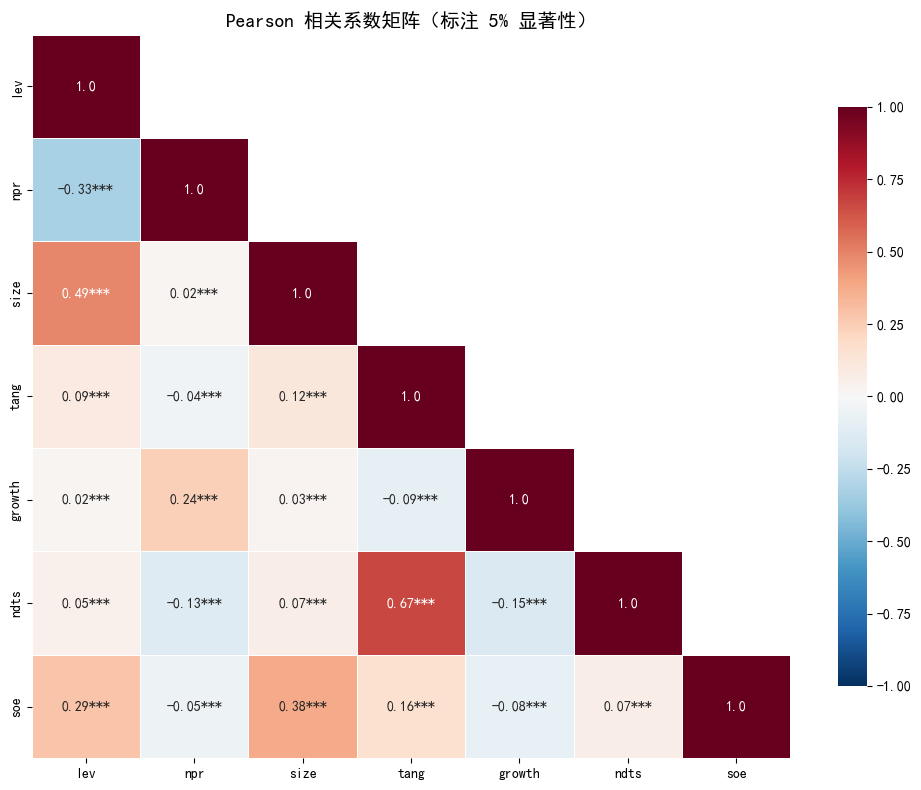

In [3]:
# %% [cell 3] 2.2 相关系数矩阵（热力图）
corr_vars = ['lev', 'npr', 'size', 'tang', 'growth', 'ndts', 'soe']
corr_df = df[corr_vars].dropna()
corr_matrix = corr_df.corr()

# 计算 p 值矩阵（用于标注显著性）
def pearson_pval(df):
    cols = df.columns
    pvals = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r, p = stats.pearsonr(df[cols[i]], df[cols[j]])
            pvals.iloc[i, j] = p
            pvals.iloc[j, i] = p
    return pvals

p_matrix = pearson_pval(corr_df)

# 根据 p 值生成标注文本
annot = corr_matrix.round(2).astype(str)
for i in annot.index:
    for j in annot.columns:
        p = p_matrix.loc[i, j]
        if i != j:
            if p < 0.01:
                annot.loc[i, j] += '***'
            elif p < 0.05:
                annot.loc[i, j] += '**'
            elif p < 0.1:
                annot.loc[i, j] += '*'

# 绘制热力图
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=annot, fmt='', mask=mask,
            cmap='RdBu_r', vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Pearson 相关系数矩阵（标注 5% 显著性）', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_fig, "Fig3_corr_heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()

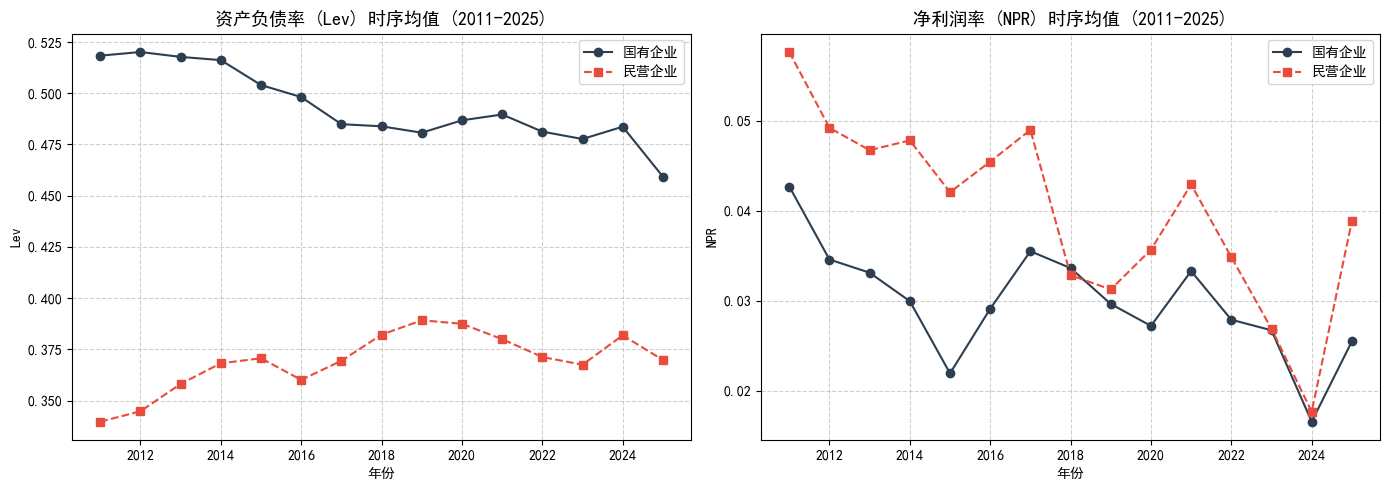

In [4]:
# %% [cell 4] 2.3 时序趋势图

# 准备分组年度均值
yearly = df.groupby(['year', 'soe']).agg(
    lev_mean=('lev', 'mean'),
    npr_mean=('npr', 'mean')
).reset_index()

# 转换为宽格式便于画图
lev_wide = yearly.pivot(index='year', columns='soe', values='lev_mean')
npr_wide = yearly.pivot(index='year', columns='soe', values='npr_mean')

# 图1: Lev 时序均值
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(lev_wide.index, lev_wide[1], 'o-', label='国有企业', color='#2c3e50')
ax.plot(lev_wide.index, lev_wide[0], 's--', label='民营企业', color='#e74c3c')
ax.set_title('资产负债率 (Lev) 时序均值 (2011-2025)', fontsize=13)
ax.set_xlabel('年份')
ax.set_ylabel('Lev')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# 图2: NPR 时序均值
ax = axes[1]
ax.plot(npr_wide.index, npr_wide[1], 'o-', label='国有企业', color='#2c3e50')
ax.plot(npr_wide.index, npr_wide[0], 's--', label='民营企业', color='#e74c3c')
ax.set_title('净利润率 (NPR) 时序均值 (2011-2025)', fontsize=13)
ax.set_xlabel('年份')
ax.set_ylabel('NPR')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(output_fig, "Fig1_Lev_NPR_timeseries.png"), dpi=300, bbox_inches='tight')
plt.show()

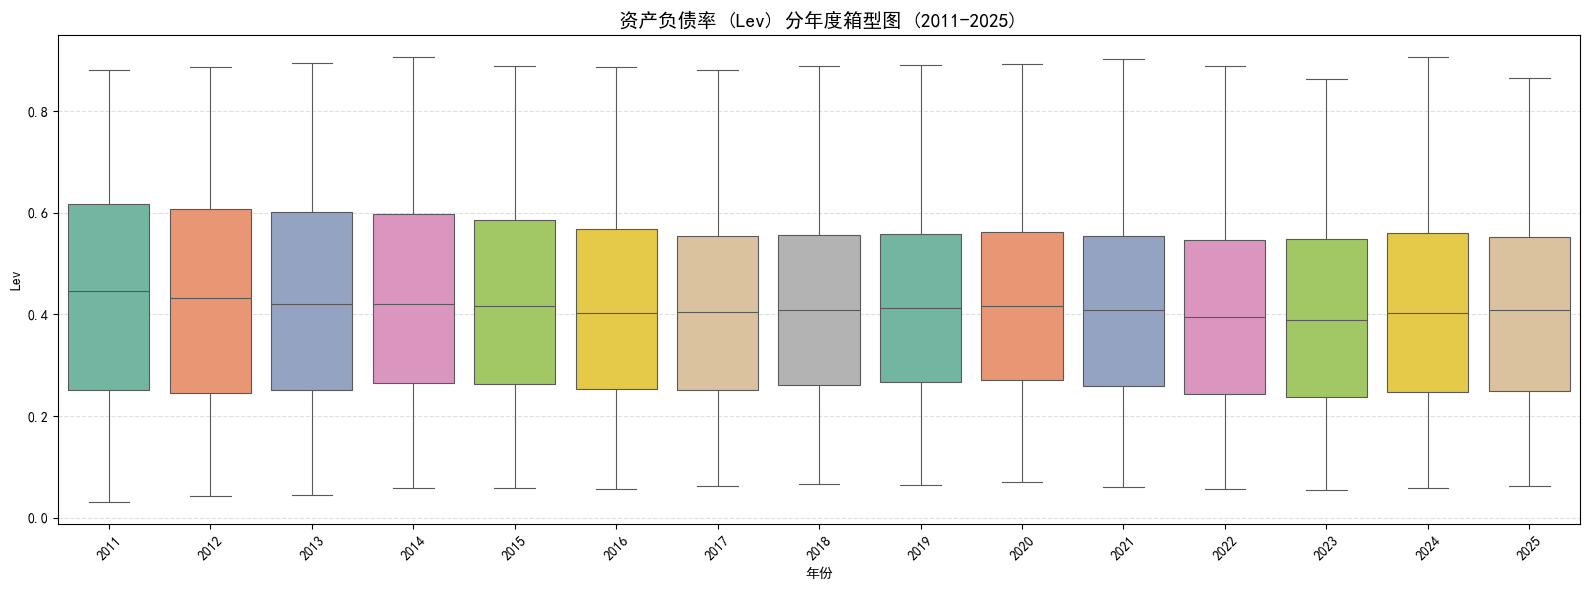

In [5]:
# %% [cell 5] 图3: Lev 分布的分年度箱型图
plt.figure(figsize=(16, 6))
sns.boxplot(x='year', y='lev', data=df, palette='Set2', linewidth=0.8)
plt.title('资产负债率 (Lev) 分年度箱型图 (2011-2025)', fontsize=14)
plt.xlabel('年份')
plt.ylabel('Lev')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(output_fig, "Fig2_Lev_boxplot_by_year.png"), dpi=300, bbox_inches='tight')
plt.show()

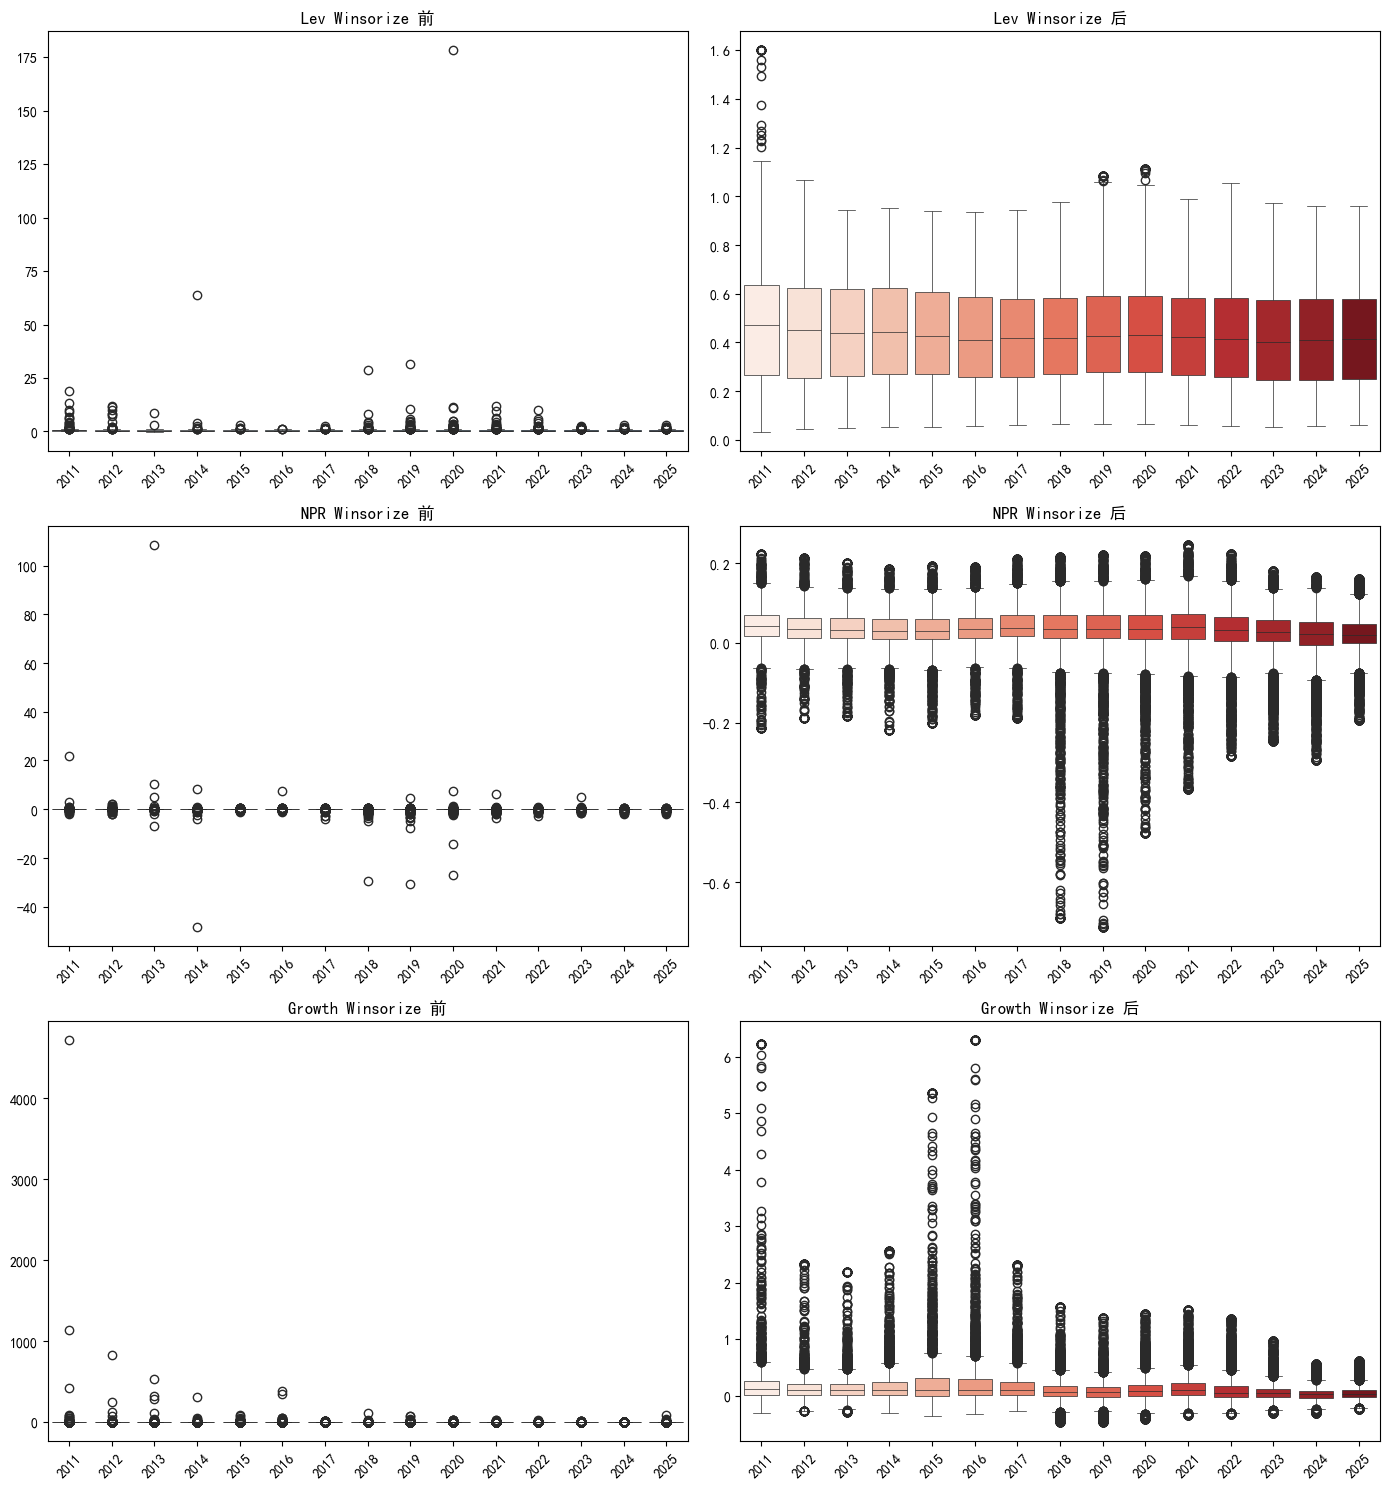

In [6]:
# %% [cell 6] Winsorize 前后对比 (Lev, NPR, Growth)

# 直接从 raw 文件中快速构建未缩尾数据
bs = pd.read_csv(os.path.join(root, "data_raw", "balance_sheet.csv"))
bs = bs[bs['Typrep']=='A']
bs['Accper'] = pd.to_datetime(bs['Accper'])
bs['year'] = bs['Accper'].dt.year
bs = bs.sort_values(['Stkcd','year','Accper']).drop_duplicates(subset=['Stkcd','year'], keep='last')
bs = bs[['Stkcd','year','A001000000','A002000000','A003000000','A001212000']]
bs.columns = ['stkcd','year','total_assets','total_liabilities','total_equity','fixed_assets']

# 利润表（获取净利润）
inc = pd.read_csv(os.path.join(root, "data_raw", "income_stmt.csv"))
inc = inc[inc['Typrep']=='A']
inc['Accper'] = pd.to_datetime(inc['Accper'])
inc['year'] = inc['Accper'].dt.year
inc = inc.sort_values(['Stkcd','year','Accper']).drop_duplicates(subset=['Stkcd','year'], keep='last')
inc = inc[['Stkcd','year','B002000000']]
inc.columns = ['stkcd','year','net_profit']

raw_df = bs.merge(inc, on=['stkcd','year'], how='inner')

# 计算三个变量
raw_df['lev'] = raw_df['total_liabilities'] / raw_df['total_assets']
raw_df['npr'] = raw_df['net_profit'] / raw_df['total_assets']
raw_df['total_assets_lag'] = raw_df.groupby('stkcd')['total_assets'].shift(1)
raw_df['growth'] = (raw_df['total_assets'] - raw_df['total_assets_lag']) / raw_df['total_assets_lag']
raw_df = raw_df.dropna(subset=['lev','npr','growth'])

# 仅保留与最终分析数据相同的公司-年份？
# 不强制，但为了可比，可限制年份范围与最终数据一致 (2011-2025)
raw_df = raw_df[(raw_df['year']>=2011) & (raw_df['year']<=2025)]

# Winsorize 函数
def winsorize_series(s):
    lower = s.quantile(0.01)
    upper = s.quantile(0.99)
    return s.clip(lower, upper)

# 对每年分别 Winsorize
raw_df['lev_win'] = raw_df.groupby('year')['lev'].transform(winsorize_series)
raw_df['npr_win'] = raw_df.groupby('year')['npr'].transform(winsorize_series)
raw_df['growth_win'] = raw_df.groupby('year')['growth'].transform(winsorize_series)

# 绘制对比箱型图：三行两列（前 vs 后）
var_names = ['Lev', 'NPR', 'Growth']
raw_cols = ['lev', 'npr', 'growth']
win_cols = ['lev_win', 'npr_win', 'growth_win']
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for i, (var, rcol, wcol) in enumerate(zip(var_names, raw_cols, win_cols)):
    ax1 = axes[i, 0]
    sns.boxplot(x='year', y=rcol, data=raw_df, ax=ax1, palette='Blues', linewidth=0.5)
    ax1.set_title(f'{var} Winsorize 前')
    ax1.set_xlabel('')
    ax1.set_ylabel('')
    ax1.tick_params(axis='x', rotation=45)
    
    ax2 = axes[i, 1]
    sns.boxplot(x='year', y=wcol, data=raw_df, ax=ax2, palette='Reds', linewidth=0.5)
    ax2.set_title(f'{var} Winsorize 后')
    ax2.set_xlabel('')
    ax2.set_ylabel('')
    ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(output_fig, "Fig_winsor_compare.png"), dpi=300, bbox_inches='tight')
plt.show()